In [1]:
from src.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from src.utils import hd_tuning, circ_colors, plot_tuning_grid, plot_intervals, find_outliers

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
import matplotlib.colors as mcolors
import umap
import umap.plot
import xarray as xr

from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.signal.windows import gaussian

import pynaviz as viz
from pynaviz import scope

# === CONFIG ===
unit_id = "116b"
WAKE_BIN = 0.1
NREM_BIN = 0.05
SMOOTH_STD = 0.2
SMOOTH_WIN = 2
UMAP_NEIGHBORS = 200
UMAP_MIN_DIST = 0.2

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)
# === FUNCTION DEFINITIONS ===

def prep_rates(spikes, epochs, bin_size=WAKE_BIN, std=SMOOTH_STD, win=SMOOTH_WIN):
    """Bin, smooth, and sqrt-transform spike counts."""
    binned = spikes.count(bin_size=bin_size, ep=epochs)
    return np.sqrt(binned.smooth(std=std, windowsize=win))

def fit_umap(data, n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, metric='cosine'):
    """Fit UMAP reducer."""
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, metric=metric)
    reducer.fit(data)
    return reducer

prj = nap.load_folder(PROCESSED_DATA_PATH.parent)
prj.view

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)


📂 ucsf
├── 📂 external
│   └── 📂 107b
├── 📂 interim
│   ├── 📂 107b
│   │   ├── 📂 umap_correlation
│   │   ├── 📂 umap_cosine
│   │   ├── 📂 umap_euclidean
│   │   ├── 📂 umap_mahalanobis
│   │   ├── 📂 umap_manhattan
│   │   ├── hd_burst_epochs.npz     |        IntervalSet
│   │   └── hd_pop_zrate.npz        |        Tsd
│   └── 📂 116b
│       └── 📂 tmp
│           ├── hd_spikes_shifted.npz   |        TsGroup
│           ├── manifold_3d_shifted.npz         |        TsdFrame
│           ├── manifold_3d_shifted_orig.npz    |        TsdFrame
│           ├── manifold_3d_shifted_wake.npz    |        TsdFrame
│           ├── manifold_shifted.npz    |        TsdFrame
│           ├── manifold_shifted_wake.npz       |        TsdFrame
│           └── sleep_shifted.npz       |        IntervalSet
├── 📂 processed
│   ├── 📂 107b
│   │   ├── active_wake.npz         |        IntervalSet
│   │   ├── angle_openfield.npz     |        Tsd
│   │   ├── hd_spikes_openfield.npz         |        TsdFrame
│   │   ├── hd_spikes_total.npz     |        TsGroup
│   │   ├── hd_spikes_wake_filtered.npz     |        TsGroup
│   │   ├── manifold_wake.npz       |        TsdFrame
│   │   ├── position_neck.npz       |        TsdFrame
│   │   ├── pupil_full_data.npz     |        TsdFrame
│   │   ├── pupil_full_normalized.npz       |        TsdFrame
│   │   ├── pupil_nrem.npz  |        TsdFrame
│   │   ├── pupil_nrem_normalized.npz       |        TsdFrame
│   │   ├── sleep.npz       |        IntervalSet
│   │   ├── spikes_shank_1.npz      |        TsGroup
│   │   ├── spikes_shank_2.npz      |        TsGroup
│   │   ├── spikes_shank_3.npz      |        TsGroup
│   │   └── turn_spikes.npz         |        TsGroup
│   └── 📂 116b
│       ├── angle_openfield.npz     |        Tsd
│       ├── angle_openfield2.npz    |        Tsd
│       ├── decoded_hd_nrem.npz     |        Tsd
│       ├── hd_spikes_filtered.npz  |        TsGroup
│       ├── hd_spikes_total.npz     |        TsGroup
│       ├── hd_spikes_wake_pre_ttx.npz      |        TsGroup
│       ├── manifold_3d_openfield2.npz      |        TsdFrame
│       ├── manifold_openfield2.npz         |        TsdFrame
│       ├── manifold_outliers_wake_pre_ttx.npz      |        IntervalSet
│       ├── manifold_wake_pre_ttx.npz       |        TsdFrame
│       ├── sessions_labeled.npz    |        IntervalSet
│       ├── sleep.npz       |        IntervalSet
│       ├── spikes_shank_1.npz      |        TsGroup
│       ├── spikes_shank_2.npz      |        TsGroup
│       ├── spikes_shank_3.npz      |        TsGroup
│       └── spikes_shank_4.npz      |        TsGroup
└── 📂 raw
    ├── 📂 107b
    └── 📂 116b

### Load

In [2]:
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

### Visualize the events

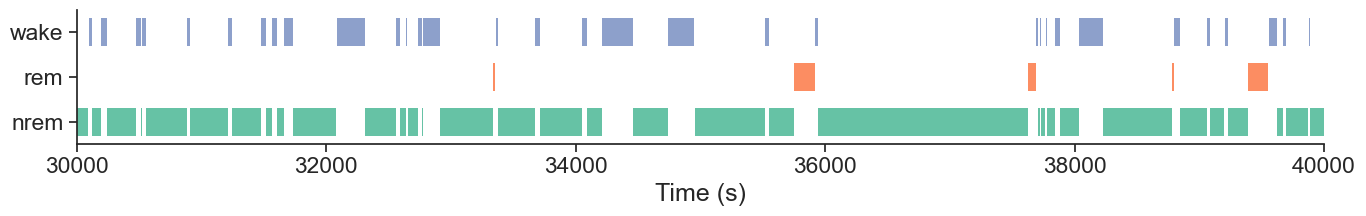

In [32]:
_ = plot_intervals(sleep_states.intersect(nap.IntervalSet(start=[30000], end=[40000])), column='state', palette='Set2')

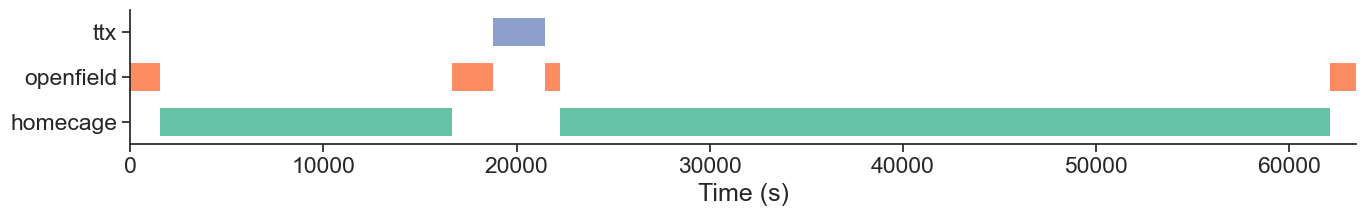

In [33]:
_ = plot_intervals(sessions, column='label', palette='Set2')

### Tuning curves

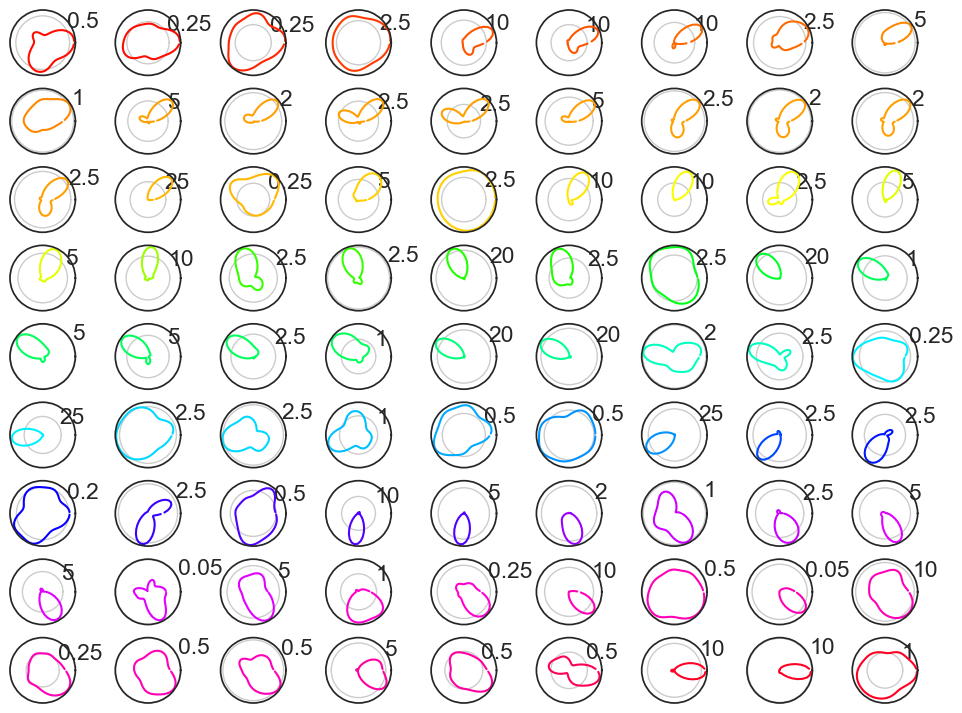

In [3]:
tcs, pref_ang = hd_tuning(hd_spikes, np.deg2rad(hd_angle))
color = xr.DataArray(circ_colors(pref_ang.values), dims=("unit", "color"), coords={"unit": pref_ang.unit})
_ = plot_tuning_grid(tcs, pref_ang, color)

<Axes: ylabel='Count'>

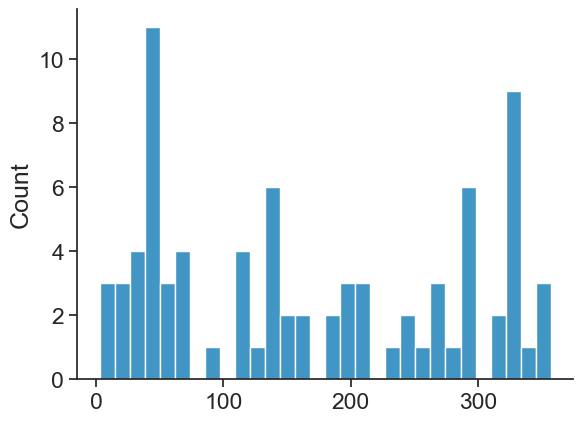

In [10]:
sns.histplot(np.rad2deg(pref_ang.values), bins=30)

Kept 47/81 units based on FWHM < 90


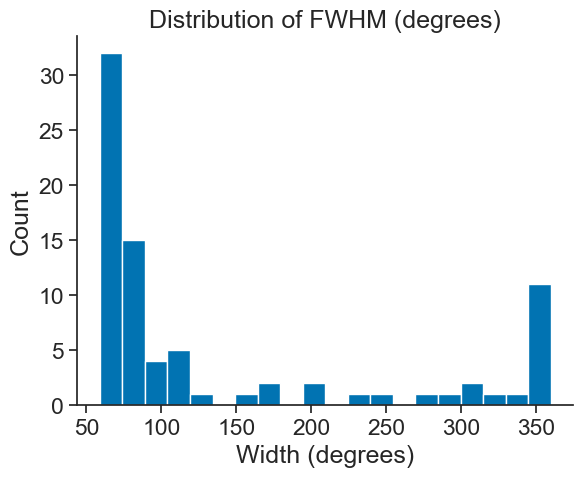

In [11]:
# --- Alternative 2: Full Width at Half Maximum (FWHM) ---
# Measures the width of the tuning curve directly in degrees/radians.

def compute_fwhm(tcs):
    """
    Compute FWHM for each tuning curve in tcs (xarray).
    Assumes tcs is (n_units, n_angles).
    Uses 'search from peak' method to handle wrapping and multi-modal noise properly.
    """
    fwhms = {}
    
    # Get angle values (check if rad or deg, usually rad in outputs of hd_tuning)
    angles = tcs.coords['head_direction'].values
    n_bins = len(angles)
    bin_width = 2 * np.pi / n_bins 
    
    for unit in tcs.coords['unit'].values:
        curve = tcs.sel(unit=unit).values
        peak_idx = np.argmax(curve)
        peak_val = curve[peak_idx]
        half_max = peak_val / 2.0
        
        # Search Left (Counter-Clockwise)
        left_idx = peak_idx
        found_left = False
        for i in range(n_bins):
            curr_idx = (peak_idx - i) % n_bins
            if curve[curr_idx] < half_max:
                left_idx = curr_idx # Found crossing point (outside)
                found_left = True
                break
        
        if not found_left:
             # Never dropped below half_max
            fwhms[unit] = 360.0
            continue

        # Search Right (Clockwise)
        right_idx = peak_idx
        for i in range(n_bins):
            curr_idx = (peak_idx + i) % n_bins
            if curve[curr_idx] < half_max:
                right_idx = curr_idx # Found crossing point (outside)
                break
        
        # Calculate width
        # Distance between crossing points.
        # Since left_idx and right_idx are the first bins *below* threshold:
        # The width is roughly the distance between them.
        n_steps = (right_idx - left_idx) % n_bins
        if n_steps == 0: n_steps = n_bins 
        
        width_rad = n_steps * bin_width
        fwhms[unit] = np.rad2deg(width_rad)
        
    return pd.Series(fwhms)

tcs_full, _ = hd_tuning(hd_spikes, np.deg2rad(hd_angle))
fwhm_values = compute_fwhm(tcs_full)

plt.figure()
plt.hist(fwhm_values.dropna(), bins=20)
plt.title("Distribution of FWHM (degrees)")
plt.xlabel("Width (degrees)")
plt.ylabel("Count")

# Filter
MAX_WIDTH = 90 # Filter curves narrower than 90 degrees
filtered_units_fwhm = fwhm_values[fwhm_values < MAX_WIDTH].index
print(f"Kept {len(filtered_units_fwhm)}/{len(hd_spikes)} units based on FWHM < {MAX_WIDTH}")

# Use intersection of filters or just one?
hd_spikes_filt = hd_spikes[filtered_units_fwhm]


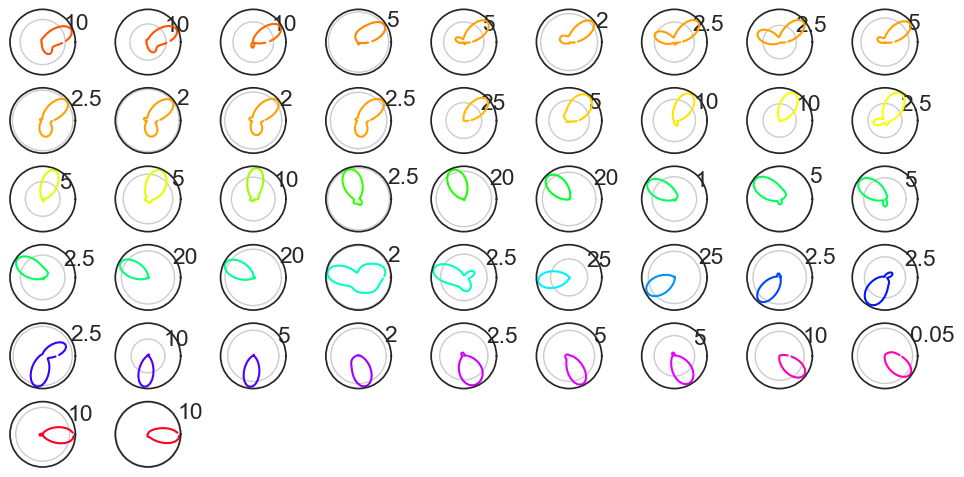

In [12]:
tcs, pref_ang = hd_tuning(hd_spikes_filt, np.deg2rad(hd_angle))
color = xr.DataArray(circ_colors(pref_ang.values), dims=("unit", "color"), coords={"unit": pref_ang.unit})
_ = plot_tuning_grid(tcs, pref_ang, color)

<Axes: ylabel='Count'>

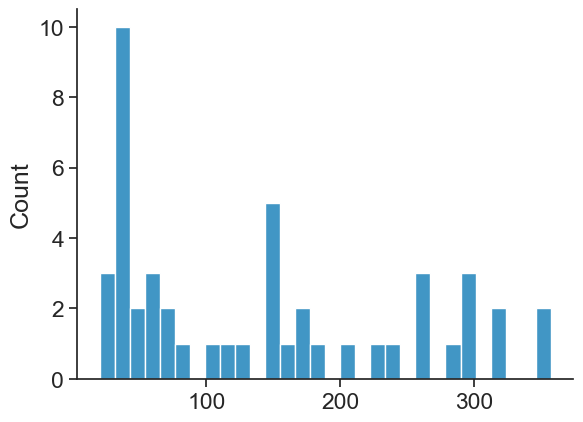

In [13]:
sns.histplot(np.rad2deg(pref_ang.values), bins=30)

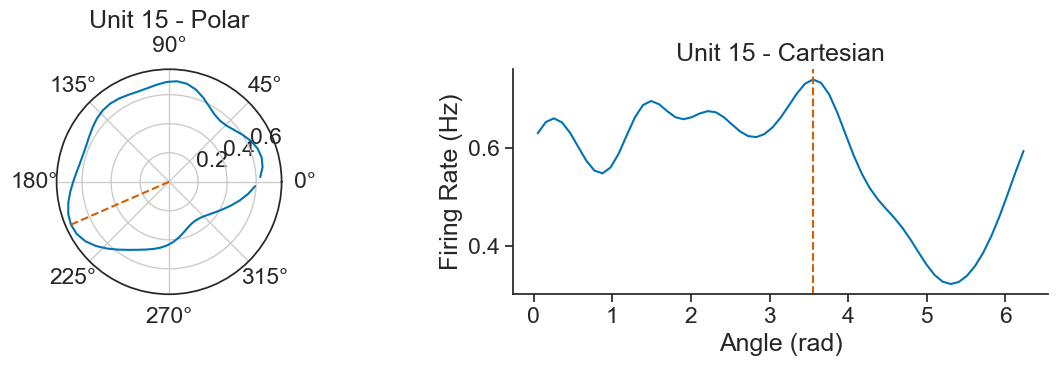

In [101]:
unit += 1
fig = plt.figure(figsize=(12, 4))

# Polar plot
ax1 = plt.subplot(121, projection='polar')
ax1.plot(tcs.coords['head_direction'].values, tcs[unit])
ax1.plot([pref_ang[unit], pref_ang[unit]], [0, tcs[unit].max()], color='r', linestyle='--')
ax1.set_title(f"Unit {unit} - Polar")

# Cartesian plot
ax2 = plt.subplot(122)
ax2.plot(tcs.coords['head_direction'].values, tcs[unit])
ax2.axvline(pref_ang[unit], color='r', linestyle='--')
ax2.set_xlabel("Angle (rad)")
ax2.set_ylabel("Firing Rate (Hz)")
ax2.set_title(f"Unit {unit} - Cartesian")

plt.tight_layout()

In [36]:
hd_spikes = hd_spikes_filt

### Wake manifold

Preprocessing

In [45]:
epochs = hd_angle.time_support

wake_rate shape: (21095, 81)


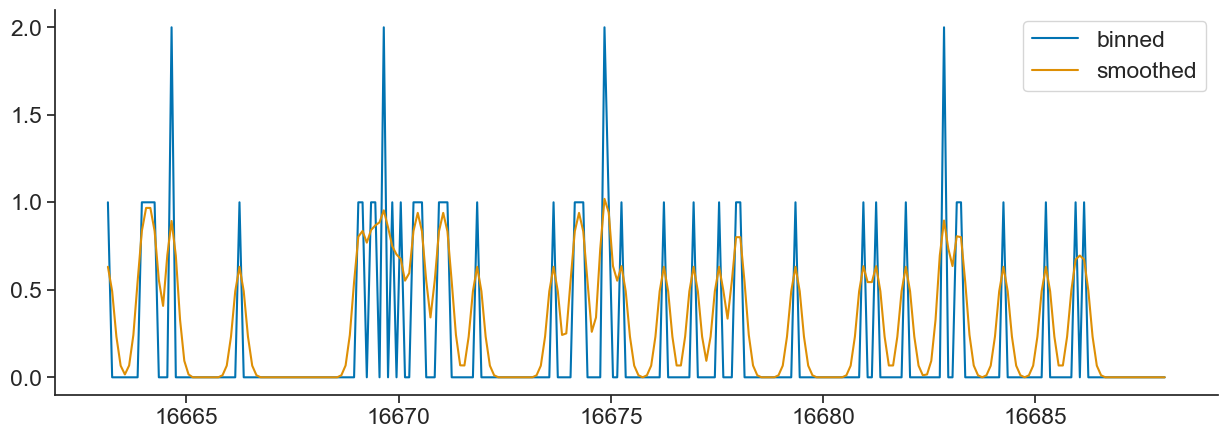

In [ ]:
WAKE_BIN = 0.1
SMOOTH_STD = 0.2
SMOOTH_WIN = 1

hd_angle = hd_angle.bin_average(bin_size=WAKE_BIN, ep=epochs)
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=epochs)
wake_rate = np.sqrt(binned.smooth(std=SMOOTH_STD, windowsize=SMOOTH_WIN))

print(f"wake_rate shape: {wake_rate.shape}")

# Smoothing effect
t_a, t_b = 0, 250
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(wake_rate[t_a:t_b, channel])
plt.legend(['binned', 'smoothed'])

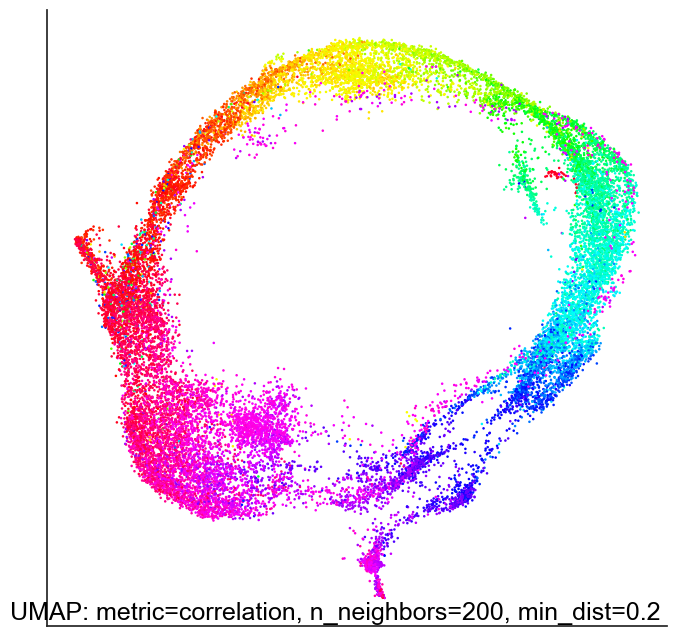

In [47]:
reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='correlation')
reducer.fit(wake_rate)
wake_embds = reducer.embedding_
_ = umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

In [20]:
import dotenv
import os

os.environ['DATA_PATH']

'D:/common_datasets/ucsf'

In [ ]:
nap.TsdFrame(t=wake_rate.t, d=wake_embds, columns=['x', 'y']).save(PROCESSED_DATA_PATH / unit_id / "manifold_openfield2.npz")
hd_angle.save(PROCESSED_DATA_PATH / unit_id / "angle_openfield2.npz")
# nap.TsdFrame(t=wake_rate.t, d=wake_embds, columns=['x', 'y', 'z']).save(PROCESSED_DATA_PATH / unit_id / "manifold_3d_openfield2.npz")

### NREM projection

smooth_rate shape: (200000, 44)


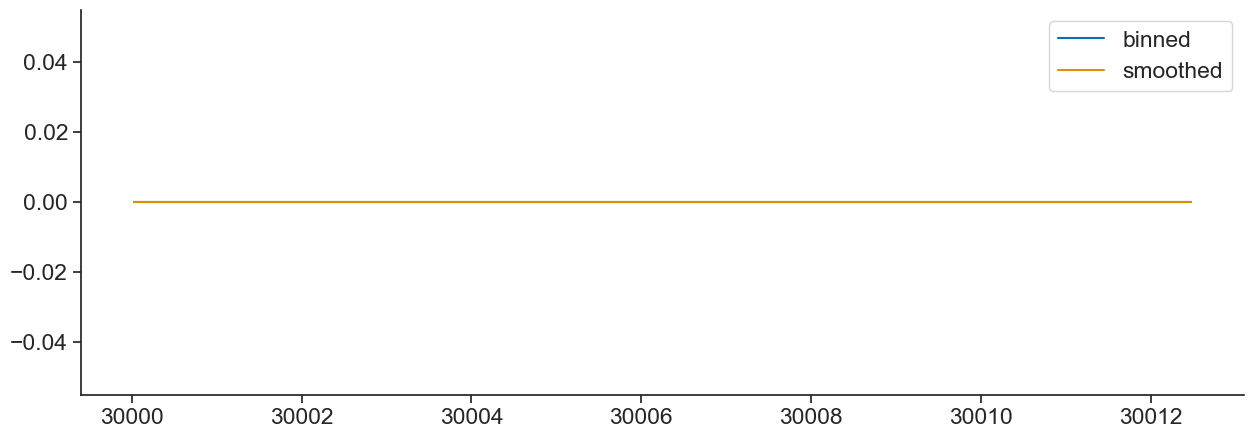

In [111]:
epochs = nap.IntervalSet(start=[30000], end=[40000])

bin_size = NREM_BIN
std = 0.05
win = 0.5

binned = hd_spikes.count(bin_size=bin_size, ep=epochs)
smooth_rate = np.sqrt(binned.smooth(std=std, windowsize=win))
print(f"smooth_rate shape: {smooth_rate.shape}")

# Smoothing effect
t_a, t_b = 0, 250
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(smooth_rate[t_a:t_b, channel])
plt.legend(['binned', 'smoothed'])

In [ ]:
sleep_embds = reducer.transform(smooth_rate)
manifold = nap.TsdFrame(t=smooth_rate.t, d=sleep_embds, columns=['x', 'y'])

ValueError: Could not find embedding attribute of umap_object

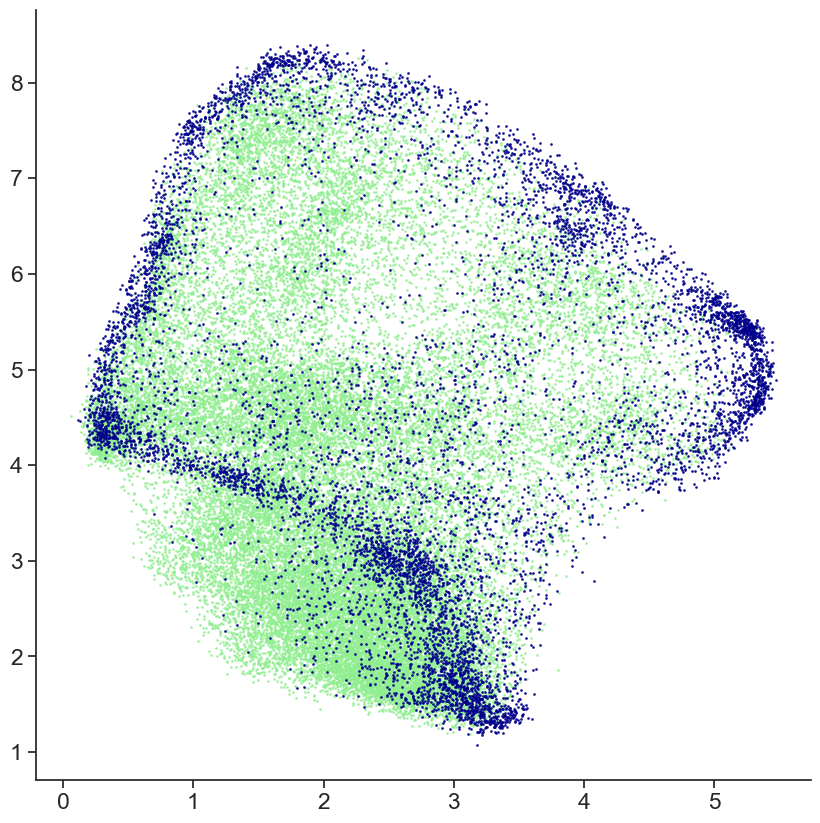

In [114]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter( x = manifold.restrict(sleep_states[sleep_states['state'] == 'wake'])[:, 0], 
            y = manifold.restrict(sleep_states[sleep_states['state'] == 'wake'])[:, 1],
            c='lightgreen', s=1, alpha=0.7)


# ax.scatter( x = manifold.restrict(sleep_states[sleep_states['state'] == 'nrem'])[:, 0], 
#             y = manifold.restrict(sleep_states[sleep_states['state'] == 'nrem'])[:, 1],
#             c='gold', s=1, alpha=0.5)

ax.scatter( x = manifold.restrict(sleep_states[sleep_states['state'] == 'rem'])[:, 0], 
            y = manifold.restrict(sleep_states[sleep_states['state'] == 'rem'])[:, 1],
            c='darkblue', s=1, alpha=0.8)


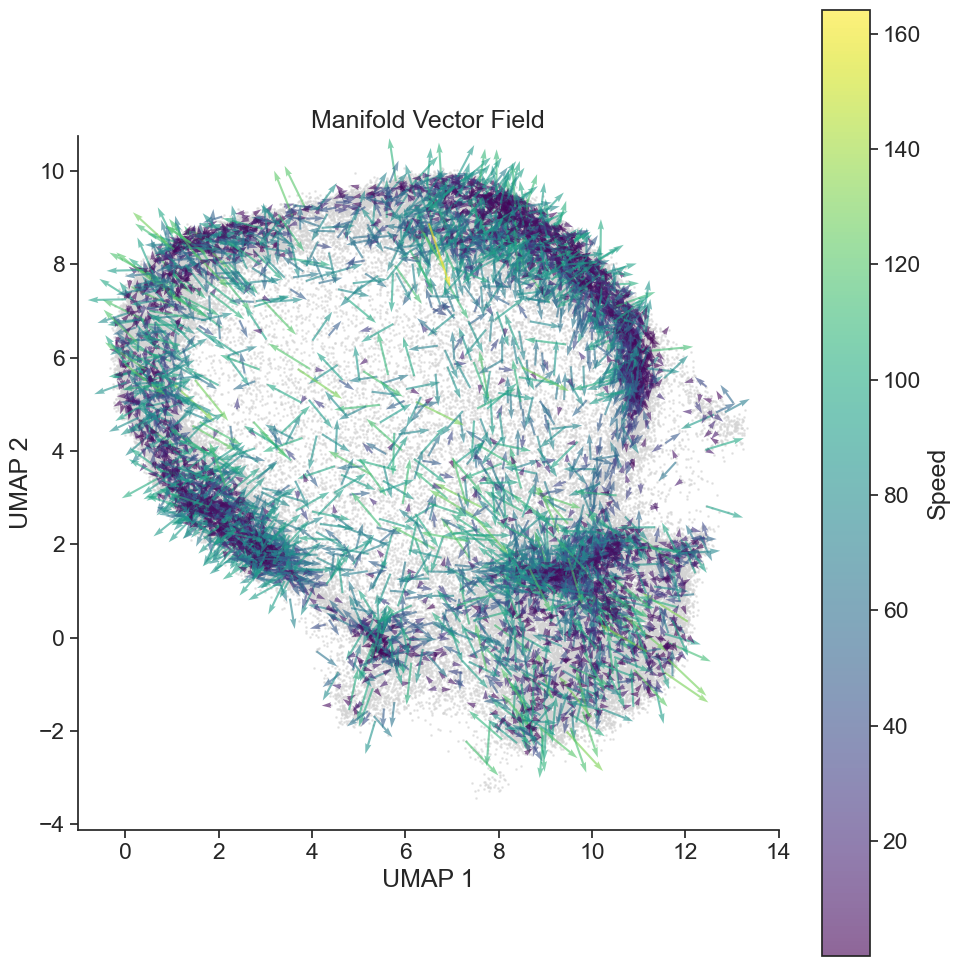

In [15]:
# data = manifold
data = manifold.restrict(sleep_states[sleep_states['state'] == 'nrem'])
    
# Compute velocity vectors using pynapple's derivative method
velocity = data.derivative()
vx = velocity['x'].values
vy = velocity['y'].values

# Compute speed (magnitude)
speed = np.sqrt(vx**2 + vy**2)

# Normalize by maximum speed with minimum length constraint
max_speed = np.quantile(speed, 0.99)
min_length = 0.2  # minimum arrow length (fraction of max, adjust as needed)

# Clip speed to have a minimum value for arrow length
speed_clipped = np.clip(speed, min_length * max_speed, None)

# Normalize vectors but scale by clipped speed
vx_norm = (vx / (speed + 1e-10)) * (speed_clipped / max_speed)
vy_norm = (vy / (speed + 1e-10)) * (speed_clipped / max_speed)

# Get positions at velocity timestamps (derivative uses midpoints)
x_pos = data['x'].restrict(velocity.time_support).values
y_pos = data['y'].restrict(velocity.time_support).values

# Subsample for clearer visualization (every nth point)
step = 25  # adjust for density of arrows

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the trajectory as faint background
ax.scatter(data['x'].values, data['y'].values, c='lightgray', s=1, alpha=0.5)

# Plot normalized velocity vectors
q = ax.quiver(x_pos[::step], y_pos[::step],
              vx_norm[::step], vy_norm[::step],
              speed[::step],  # color by original speed
              cmap='viridis', alpha=0.6,
              scale=15,
              width=0.003)

plt.colorbar(q, label='Speed')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Manifold Vector Field')
ax.set_aspect('equal')
plt.tight_layout()

### Viz

In [19]:
scope({'sleep': sleep_states, 'units': hd_spikes, 'manifold': manifold})

In [117]:
# === Time-shift data to start from zero ===
# Define the epoch of interest
t_start = 30000
t_end = 40000
viz_epoch = nap.IntervalSet(start=[t_start], end=[t_end])

# Create output directory
output_dir = INTERIM_DATA_PATH / unit_id / 'tmp'
output_dir.mkdir(parents=True, exist_ok=True)

In [121]:
# --- Shift sleep_states ---
sleep_restricted = sleep_states.intersect(viz_epoch)
sleep_shifted = nap.IntervalSet(
    start=sleep_restricted['start'] - t_start,
    end=sleep_restricted['end'] - t_start,
    metadata=sleep_restricted.metadata
)
sleep_shifted.save(output_dir / "sleep_shifted.npz")

# --- Shift spike trains ---
hd_spikes_restricted = hd_spikes.restrict(viz_epoch)
shifted_spikes = {}
for unit, ts in hd_spikes_restricted.items():
    shifted_spikes[unit] = nap.Ts(t=ts.times() - t_start)

hd_spikes_shifted = nap.TsGroup(shifted_spikes, metadata=hd_spikes.metadata.drop(columns=['rate']))
hd_spikes_shifted.save(output_dir / "hd_spikes_shifted.npz")

# --- Shift manifold ---
manifold_restricted = manifold.restrict(viz_epoch)
manifold_shifted = nap.TsdFrame(
    t=manifold_restricted.times() - t_start,
    d=manifold_restricted.values,
    columns=manifold_restricted.columns
)
manifold_shifted.save(output_dir / "manifold_shifted.npz")

print(f"Data saved to: {output_dir}")
print(f"Time range shifted from [{t_start}, {t_end}] to [0, {t_end - t_start}]")
print(f"  - sleep_shifted.npz: {len(sleep_shifted)} intervals")
print(f"  - hd_spikes_shifted.npz: {len(hd_spikes_shifted)} units")
print(f"  - manifold_shifted.npz: {len(manifold_shifted)} samples")

Data saved to: D:\common_datasets\ucsf\interim\116b\tmp
Time range shifted from [30000, 40000] to [0, 10000]
  - sleep_shifted.npz: 70 intervals
  - hd_spikes_shifted.npz: 44 units
  - manifold_shifted.npz: 200000 samples


In [120]:
# --- Shift manifold ---
manifold_restricted = manifold.restrict(viz_epoch)
manifold_shifted = nap.TsdFrame(
    t=manifold_restricted.times() - t_start,
    d=manifold_restricted.values,
    columns=manifold_restricted.columns
)
manifold_shifted.save(output_dir / "manifold_shifted_wake.npz")